<a href="https://colab.research.google.com/github/Leila828/alzheimer_oasis_transfer_learning/blob/main/alzheimer_oasis_transfer_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Alzheimer's Disease Prediction — OASIS Dataset
## Transfer Learning Comparison: VGG16 · ResNet50 · InceptionV3 · MobileNetV2 · EfficientNetB0

**Colab-friendly settings:**
- ✅ Max 200 images per class (subsetting for free GPU)
- ✅ 10 epochs per model
- ✅ Grad-CAM visualisation
- ✅ Side-by-side accuracy/loss comparison
- ✅ Ensemble / merge strategy discussion at the end

## 1 · Setup & Kaggle Dataset Download

In [ ]:
export KAGGLE_API_TOKEN=KGAT_68c2833a7926e5e424ecc96d7b3a3c88

In [ ]:
# ── Install kaggle API ─────────────────────────────────────────────────────
!pip install -q kaggle

# Upload your kaggle.json here (Menu → Files → Upload)
from google.colab import files
print('Upload your kaggle.json API token:')
files.upload()

Upload your kaggle.json API token:


Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"habibleila","key":"eebdce50274f94dc9bad6bf856d5d702"}'}

In [ ]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

# Download OASIS dataset
!kaggle datasets download -d ninadaithal/imagesoasis -p /content/oasis --unzip
!ls /content/oasis

Dataset URL: https://www.kaggle.com/datasets/ninadaithal/imagesoasis
License(s): apache-2.0
100% 1.23G/1.23G [01:19<00:00, 16.6MB/s]

Data


## 2 · Imports & Global Config

In [ ]:
import os, shutil, random, warnings, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import (
    VGG16, ResNet50, InceptionV3, MobileNetV2, EfficientNetB0
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import cv2

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

# ─── GLOBAL CONFIG (tweak for your Colab tier) ───────────────────────────
IMG_SIZE        = 224          # InceptionV3 needs ≥75; all others work at 224
BATCH_SIZE      = 32
EPOCHS          = 10           # Keep low for free Colab
MAX_PER_CLASS   = 200          # Subsample to save RAM / time
FINE_TUNE_AFTER = 5            # Resume training with unfrozen top layers after N epochs
LEARNING_RATE   = 1e-4
DATA_ROOT       = '/content/oasis'
SUBSET_ROOT     = '/content/oasis_subset'
RESULTS         = {}           # Store per-model results here

print('TF version:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TF version: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 3 · Dataset Exploration & Subsetting

In [ ]:
# ─── Explore raw structure ────────────────────────────────────────────────
data_path = Path(DATA_ROOT)
# Find the folder that contains class sub-folders
for p in sorted(data_path.rglob('*')):
    if p.is_dir():
        imgs = list(p.glob('*.jpg')) + list(p.glob('*.png')) + list(p.glob('*.jpeg'))
        if imgs:
            print(f'{p.relative_to(data_path)}: {len(imgs)} images')

Data/Mild Dementia: 5002 images
Data/Moderate Dementia: 488 images
Data/Non Demented: 67222 images
Data/Very mild Dementia: 13725 images


In [ ]:
# ─── Auto-detect class folders ───────────────────────────────────────────
# Adjust this path if the dataset unpacks differently
# Common OASIS structure: Data/train/{class}/ or directly /{class}/

def find_class_dirs(root):
    root = Path(root)
    for p in sorted(root.rglob('*')):
        if p.is_dir():
            imgs = list(p.glob('*.jpg')) + list(p.glob('*.png')) + list(p.glob('*.jpeg'))
            if len(imgs) > 10:
                siblings = [s for s in p.parent.iterdir() if s.is_dir()]
                if len(siblings) >= 2:
                    return p.parent
    return root

CLASS_ROOT = find_class_dirs(DATA_ROOT)
CLASSES    = sorted([d.name for d in CLASS_ROOT.iterdir() if d.is_dir()])
print('Detected class root:', CLASS_ROOT)
print('Classes:', CLASSES)

Detected class root: /content/oasis/Data
Classes: ['Mild Dementia', 'Moderate Dementia', 'Non Demented', 'Very mild Dementia']


In [ ]:
# ─── Build balanced subset ────────────────────────────────────────────────
def build_subset(class_root, subset_root, classes, max_per_class, split=(0.7, 0.15, 0.15)):
    subset_root = Path(subset_root)
    if subset_root.exists():
        shutil.rmtree(subset_root)
    for split_name in ['train', 'val', 'test']:
        for cls in classes:
            (subset_root / split_name / cls).mkdir(parents=True, exist_ok=True)

    for cls in classes:
        imgs = (list((class_root / cls).glob('*.jpg')) +
                list((class_root / cls).glob('*.png')) +
                list((class_root / cls).glob('*.jpeg')))
        random.shuffle(imgs)
        imgs = imgs[:max_per_class]
        n = len(imgs)
        n_train = int(n * split[0])
        n_val   = int(n * split[1])
        splits  = {'train': imgs[:n_train],
                   'val':   imgs[n_train:n_train+n_val],
                   'test':  imgs[n_train+n_val:]}
        for split_name, paths in splits.items():
            for p in paths:
                shutil.copy(p, subset_root / split_name / cls / p.name)
        print(f'  {cls}: train={len(splits["train"])}, val={len(splits["val"])}, test={len(splits["test"])}')

print('Building balanced subset …')
build_subset(CLASS_ROOT, SUBSET_ROOT, CLASSES, MAX_PER_CLASS)
print('Done.')

Building balanced subset …
  Mild Dementia: train=140, val=30, test=30
  Moderate Dementia: train=140, val=30, test=30
  Non Demented: train=140, val=30, test=30
  Very mild Dementia: train=140, val=30, test=30
Done.


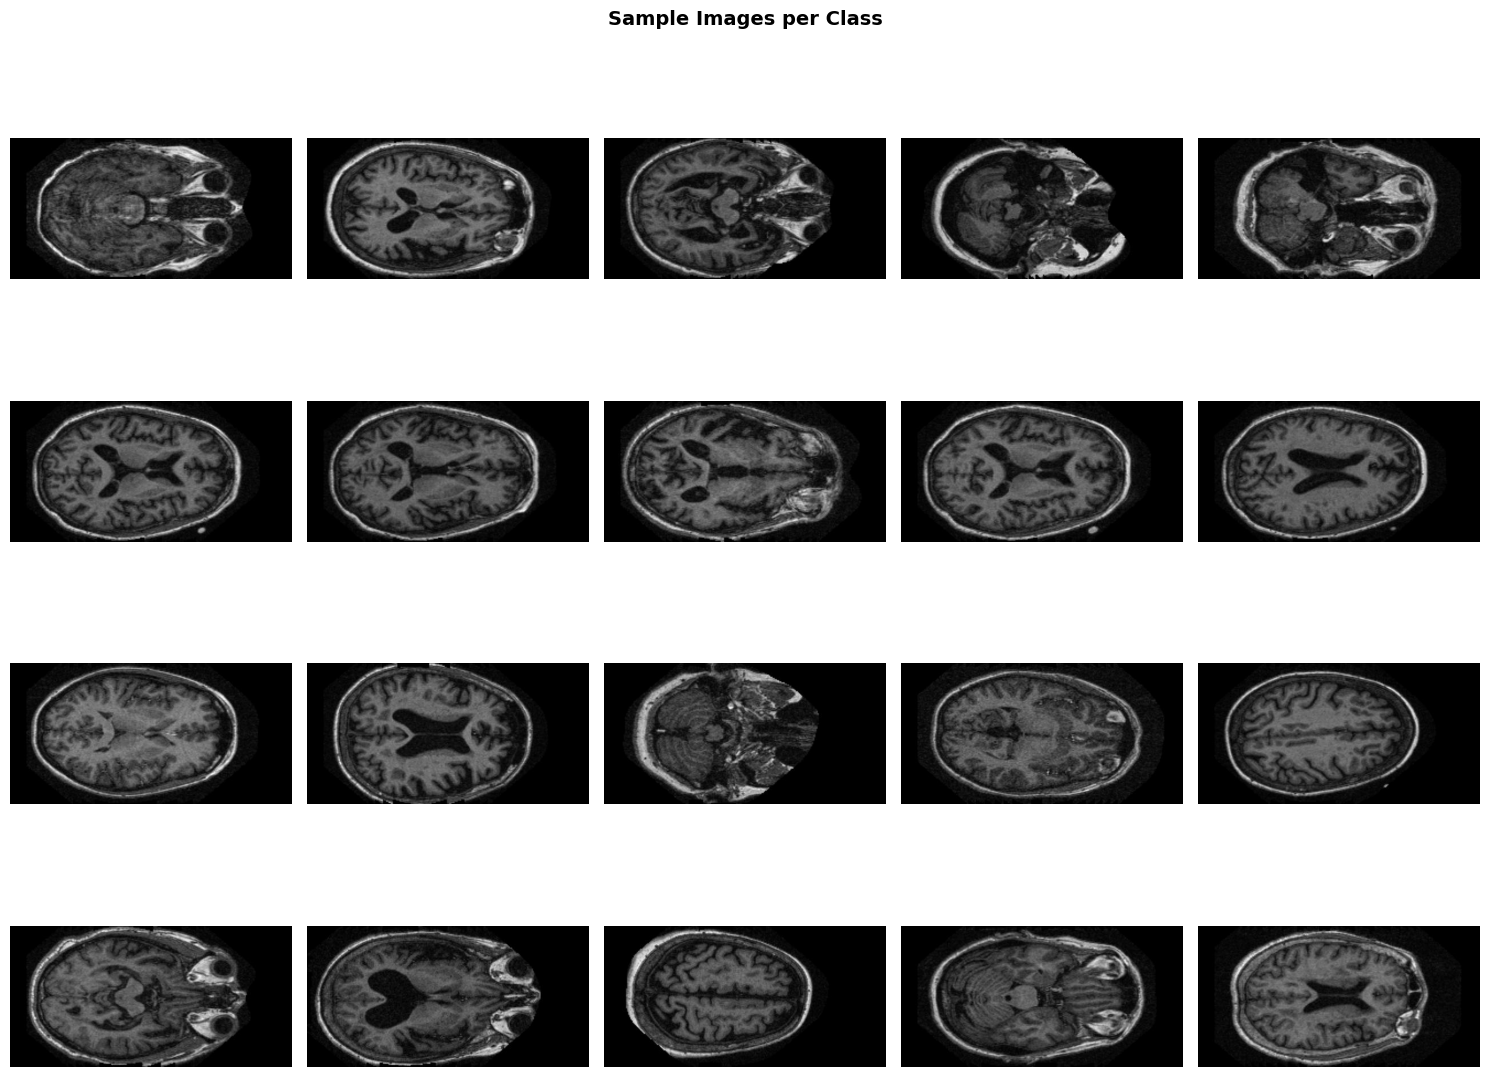

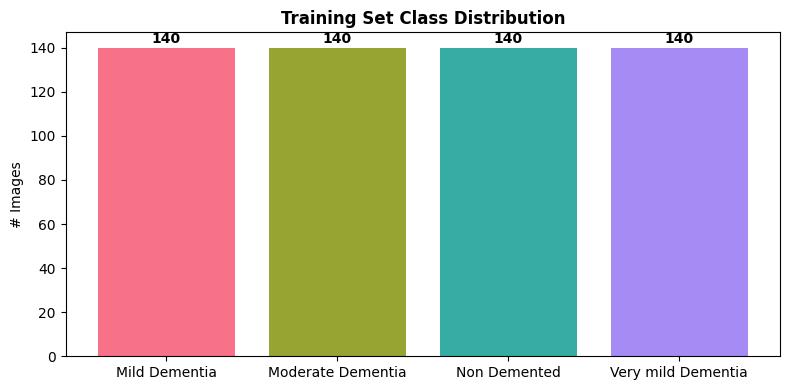

In [ ]:
# ─── Visualise sample images per class ───────────────────────────────────
fig, axes = plt.subplots(len(CLASSES), 5, figsize=(15, 3*len(CLASSES)))
for r, cls in enumerate(CLASSES):
    imgs = list((Path(SUBSET_ROOT) / 'train' / cls).glob('*'))[:5]
    for c, img_path in enumerate(imgs):
        img = plt.imread(img_path)
        ax  = axes[r, c] if len(CLASSES) > 1 else axes[c]
        ax.imshow(img, cmap='gray' if img.ndim == 2 else None)
        ax.axis('off')
        if c == 0:
            ax.set_ylabel(cls, fontsize=11, fontweight='bold')
plt.suptitle('Sample Images per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/sample_images.png', dpi=100, bbox_inches='tight')
plt.show()

# Class distribution bar chart
class_counts = {cls: len(list((Path(SUBSET_ROOT)/'train'/cls).glob('*'))) for cls in CLASSES}
plt.figure(figsize=(8, 4))
bars = plt.bar(class_counts.keys(), class_counts.values(),
               color=sns.color_palette('husl', len(CLASSES)))
plt.title('Training Set Class Distribution', fontweight='bold')
plt.ylabel('# Images')
for bar, val in zip(bars, class_counts.values()):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, str(val),
             ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/class_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

## 4 · Data Generators

In [ ]:
def make_generators(img_size=IMG_SIZE, batch_size=BATCH_SIZE):
    train_aug = ImageDataGenerator(
        rescale=1./255,
        rotation_range=15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True,
        zoom_range=0.1,
        fill_mode='nearest'
    )
    val_aug = ImageDataGenerator(rescale=1./255)

    train_gen = train_aug.flow_from_directory(
        f'{SUBSET_ROOT}/train', target_size=(img_size, img_size),
        batch_size=batch_size, class_mode='categorical', shuffle=True, seed=42
    )
    val_gen = val_aug.flow_from_directory(
        f'{SUBSET_ROOT}/val', target_size=(img_size, img_size),
        batch_size=batch_size, class_mode='categorical', shuffle=False
    )
    test_gen = val_aug.flow_from_directory(
        f'{SUBSET_ROOT}/test', target_size=(img_size, img_size),
        batch_size=batch_size, class_mode='categorical', shuffle=False
    )
    return train_gen, val_gen, test_gen

train_gen, val_gen, test_gen = make_generators()
NUM_CLASSES = len(CLASSES)
print('Classes:', train_gen.class_indices)

Found 560 images belonging to 4 classes.
Found 120 images belonging to 4 classes.
Found 120 images belonging to 4 classes.
Classes: {'Mild Dementia': 0, 'Moderate Dementia': 1, 'Non Demented': 2, 'Very mild Dementia': 3}


## 5 · Model Builder

In [ ]:
def build_model(backbone_fn, name, img_size=IMG_SIZE, num_classes=NUM_CLASSES):
    """Builds a transfer learning model with a custom classification head."""
    # InceptionV3 needs input size ≥ 75; others are fine at 224
    input_shape = (img_size, img_size, 3)

    base = backbone_fn(
        weights='imagenet', include_top=False,
        input_shape=input_shape
    )
    base.trainable = False   # Freeze for initial training

    inputs = keras.Input(shape=input_shape)
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs, name=name)
    model.compile(
        optimizer=keras.optimizers.Adam(LEARNING_RATE),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model, base

# Registry of architectures to compare
ARCHITECTURES = {
    'VGG16'         : VGG16,
    'ResNet50'      : ResNet50,
    'InceptionV3'   : InceptionV3,
    'MobileNetV2'   : MobileNetV2,
    'EfficientNetB0': EfficientNetB0,
}
print('Architectures to train:', list(ARCHITECTURES.keys()))

Architectures to train: ['VGG16', 'ResNet50', 'InceptionV3', 'MobileNetV2', 'EfficientNetB0']


## 6 · Training Loop (All Models)

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1, min_lr=1e-7)
]

HISTORIES  = {}
MODELS     = {}

for arch_name, backbone_fn in ARCHITECTURES.items():
    print(f'\n{'='*60}')
    print(f'  Training: {arch_name}')
    print(f'{'='*60}')

    # Re-create generators each time (avoids state issues)
    train_gen, val_gen, test_gen = make_generators()

    model, base = build_model(backbone_fn, arch_name)

    t0 = time.time()
    # ── Phase 1: Frozen base ─────────────────────────────────────────────
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=FINE_TUNE_AFTER,
        callbacks=callbacks,
        verbose=1
    )

    # ── Phase 2: Fine-tune top 20 layers of base ─────────────────────────
    base.trainable = True
    for layer in base.layers[:-20]:
        layer.trainable = False
    model.compile(
        optimizer=keras.optimizers.Adam(LEARNING_RATE / 10),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    history2 = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS - FINE_TUNE_AFTER,
        callbacks=callbacks,
        verbose=1
    )

    # Merge histories
    combined = {}
    for k in history.history:
        combined[k] = history.history[k] + history2.history[k]

    t1 = time.time()

    # Evaluate on test set
    test_gen.reset()
    loss, acc = model.evaluate(test_gen, verbose=0)

    HISTORIES[arch_name]  = combined
    MODELS[arch_name]     = model
    RESULTS[arch_name]    = {
        'test_acc' : acc,
        'test_loss': loss,
        'time_min' : (t1-t0)/60,
        'params'   : model.count_params()
    }
    print(f'  Test Acc: {acc:.4f} | Loss: {loss:.4f} | Time: {(t1-t0)/60:.1f} min')


  Training: VGG16
Found 560 images belonging to 4 classes.
Found 120 images belonging to 4 classes.
Found 120 images belonging to 4 classes.
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.2696 - loss: 1.5837 - val_accuracy: 0.2583 - val_loss: 1.3965 - learning_rate: 1.0000e-04
Epoch 2/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 514ms/step - accuracy: 0.3286 - loss: 1.4816 - val_accuracy: 0.2833 - val_loss: 1.3837 - learning_rate: 1.0000e-04
Epoch 3/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 526ms/step - accuracy: 0.3464 - loss: 1.4271 - val_accuracy: 0.2750 - val_loss: 1.3742 - learning_rate: 1.0000e-04
Epoch 4/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 452ms/step - accuracy: 0.3446 - loss: 1.4145 - val_accuracy: 0.2667 - val_loss: 1.3655 - learning_rate: 1.0000e-04
Epoch 5/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 498ms/step - accuracy: 0.4071 - loss: 1.3251 - val_accuracy: 0.2833 - val_loss: 1.3575 - learning_rate: 1.0000e-04
Restoring model weights from the e

## 7 · Comparison Visualisations

In [ ]:
# ─── Accuracy & Loss curves side by side ─────────────────────────────────
palette = sns.color_palette('tab10', len(ARCHITECTURES))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for (arch_name, hist), color in zip(HISTORIES.items(), palette):
    epochs_range = range(1, len(hist['accuracy'])+1)
    axes[0].plot(epochs_range, hist['val_accuracy'], label=arch_name, color=color, linewidth=2)
    axes[1].plot(epochs_range, hist['val_loss'],     label=arch_name, color=color, linewidth=2)

for ax, title, ylabel in zip(axes,
    ['Validation Accuracy', 'Validation Loss'],
    ['Accuracy', 'Loss']):
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.axvline(x=FINE_TUNE_AFTER, color='gray', linestyle='--', alpha=0.5, label='Fine-tune start')

plt.suptitle('All Architectures — Training Progress', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

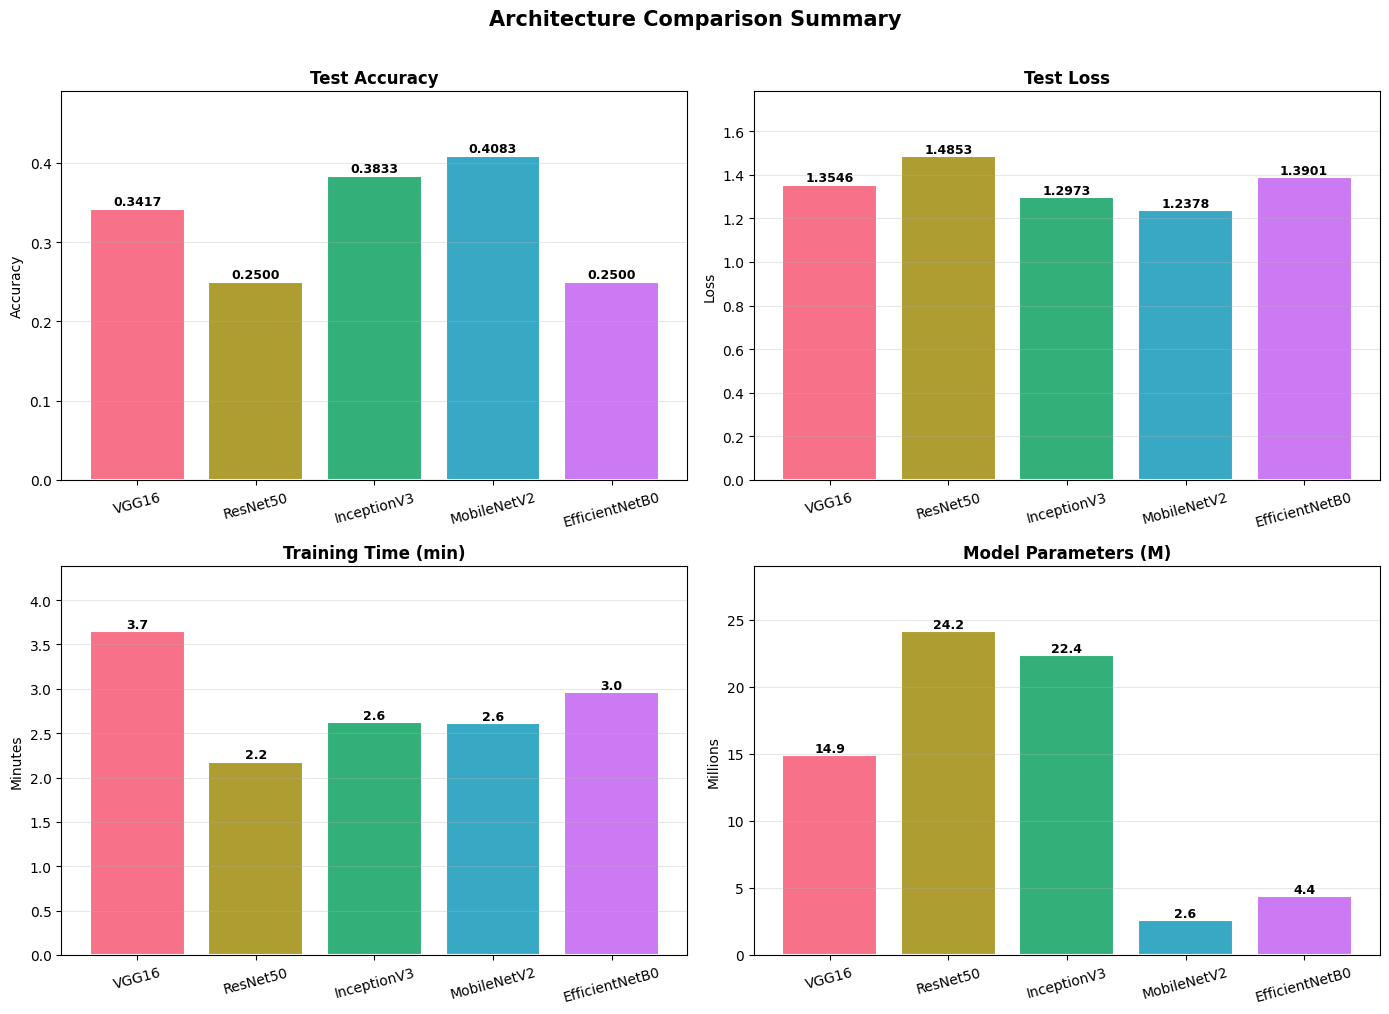

In [ ]:
# ─── Bar chart: Test Accuracy comparison ─────────────────────────────────
names   = list(RESULTS.keys())
accs    = [RESULTS[n]['test_acc']  for n in names]
losses  = [RESULTS[n]['test_loss'] for n in names]
times   = [RESULTS[n]['time_min']  for n in names]
params  = [RESULTS[n]['params']/1e6 for n in names]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = sns.color_palette('husl', len(names))

def bar_plot(ax, values, title, ylabel, fmt='{:.4f}'):
    bars = ax.bar(names, values, color=colors, edgecolor='white', linewidth=1.5)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, max(values)*1.2)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                fmt.format(val), ha='center', va='bottom', fontweight='bold', fontsize=9)
    ax.tick_params(axis='x', rotation=15)
    ax.grid(axis='y', alpha=0.3)

bar_plot(axes[0,0], accs,   'Test Accuracy',        'Accuracy',      '{:.4f}')
bar_plot(axes[0,1], losses, 'Test Loss',             'Loss',          '{:.4f}')
bar_plot(axes[1,0], times,  'Training Time (min)',   'Minutes',       '{:.1f}')
bar_plot(axes[1,1], params, 'Model Parameters (M)',  'Millions',      '{:.1f}')

plt.suptitle('Architecture Comparison Summary', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

Found 560 images belonging to 4 classes.
Found 120 images belonging to 4 classes.
Found 120 images belonging to 4 classes.
Found 560 images belonging to 4 classes.
Found 120 images belonging to 4 classes.
Found 120 images belonging to 4 classes.
Found 560 images belonging to 4 classes.
Found 120 images belonging to 4 classes.
Found 120 images belonging to 4 classes.


Found 560 images belonging to 4 classes.
Found 120 images belonging to 4 classes.
Found 120 images belonging to 4 classes.
Found 560 images belonging to 4 classes.
Found 120 images belonging to 4 classes.
Found 120 images belonging to 4 classes.


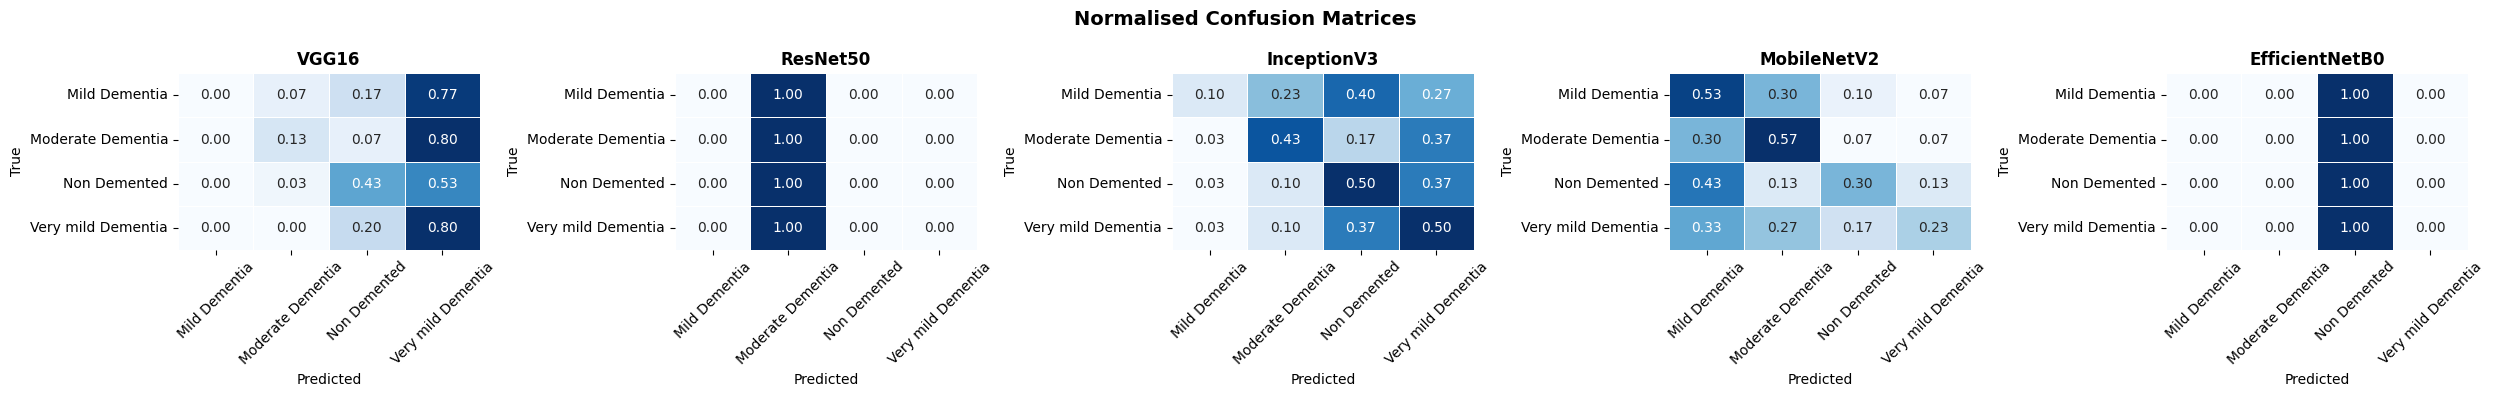

In [ ]:
# ─── Per-model confusion matrices ─────────────────────────────────────────
fig, axes = plt.subplots(1, len(ARCHITECTURES), figsize=(5*len(ARCHITECTURES), 4))

for ax, (arch_name, model) in zip(axes, MODELS.items()):
    train_gen, val_gen, test_gen = make_generators()
    test_gen.reset()
    preds = np.argmax(model.predict(test_gen, verbose=0), axis=1)
    trues = test_gen.classes
    cm    = confusion_matrix(trues, preds)
    cm_n  = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # Normalise
    sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax,
                linewidths=0.5, cbar=False)
    ax.set_title(arch_name, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Normalised Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()

## 8 · Grad-CAM Visualisation

In [ ]:
# ─── Grad-CAM helper ─────────────────────────────────────────────────────
def get_last_conv_layer(model):
    """Auto-detect the last Conv2D layer name."""
    for layer in reversed(model.layers):
        if isinstance(layer, layers.Conv2D):
            return layer.name
        # Nested in sub-model (base model)
        if hasattr(layer, 'layers'):
            for sub in reversed(layer.layers):
                if isinstance(sub, layers.Conv2D):
                    return sub.name
    return None

def make_gradcam_heatmap(img_array, model, last_conv_name, pred_index=None):
    """Compute Grad-CAM heatmap."""
    # Build sub-model that outputs last conv feature maps + final predictions
    # We walk into the base sub-model if needed
    try:
        conv_layer = model.get_layer(last_conv_name)
        grad_model = Model([model.inputs], [conv_layer.output, model.output])
    except ValueError:
        # Layer is inside a nested model
        base_model = None
        for l in model.layers:
            if hasattr(l, 'layers'):
                try:
                    _ = l.get_layer(last_conv_name)
                    base_model = l
                    break
                except:
                    pass
        conv_layer = base_model.get_layer(last_conv_name)
        grad_model = Model([model.inputs],
                           [conv_layer.output, model.output])

    with tf.GradientTape() as tape:
        img_tensor = tf.cast(img_array, tf.float32)
        conv_outputs, predictions = grad_model(img_tensor)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads    = tape.gradient(class_channel, conv_outputs)
    pooled   = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap  = conv_outputs[0] @ pooled[..., tf.newaxis]
    heatmap  = tf.squeeze(heatmap)
    heatmap  = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def overlay_gradcam(img_path, heatmap, alpha=0.4):
    img = cv2.imread(str(img_path))
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap_uint8   = np.uint8(255 * heatmap_resized)
    colormap        = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    overlay         = cv2.addWeighted(img, 1-alpha, colormap, alpha, 0)
    return cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

print('Grad-CAM helpers ready.')

Grad-CAM helpers ready.


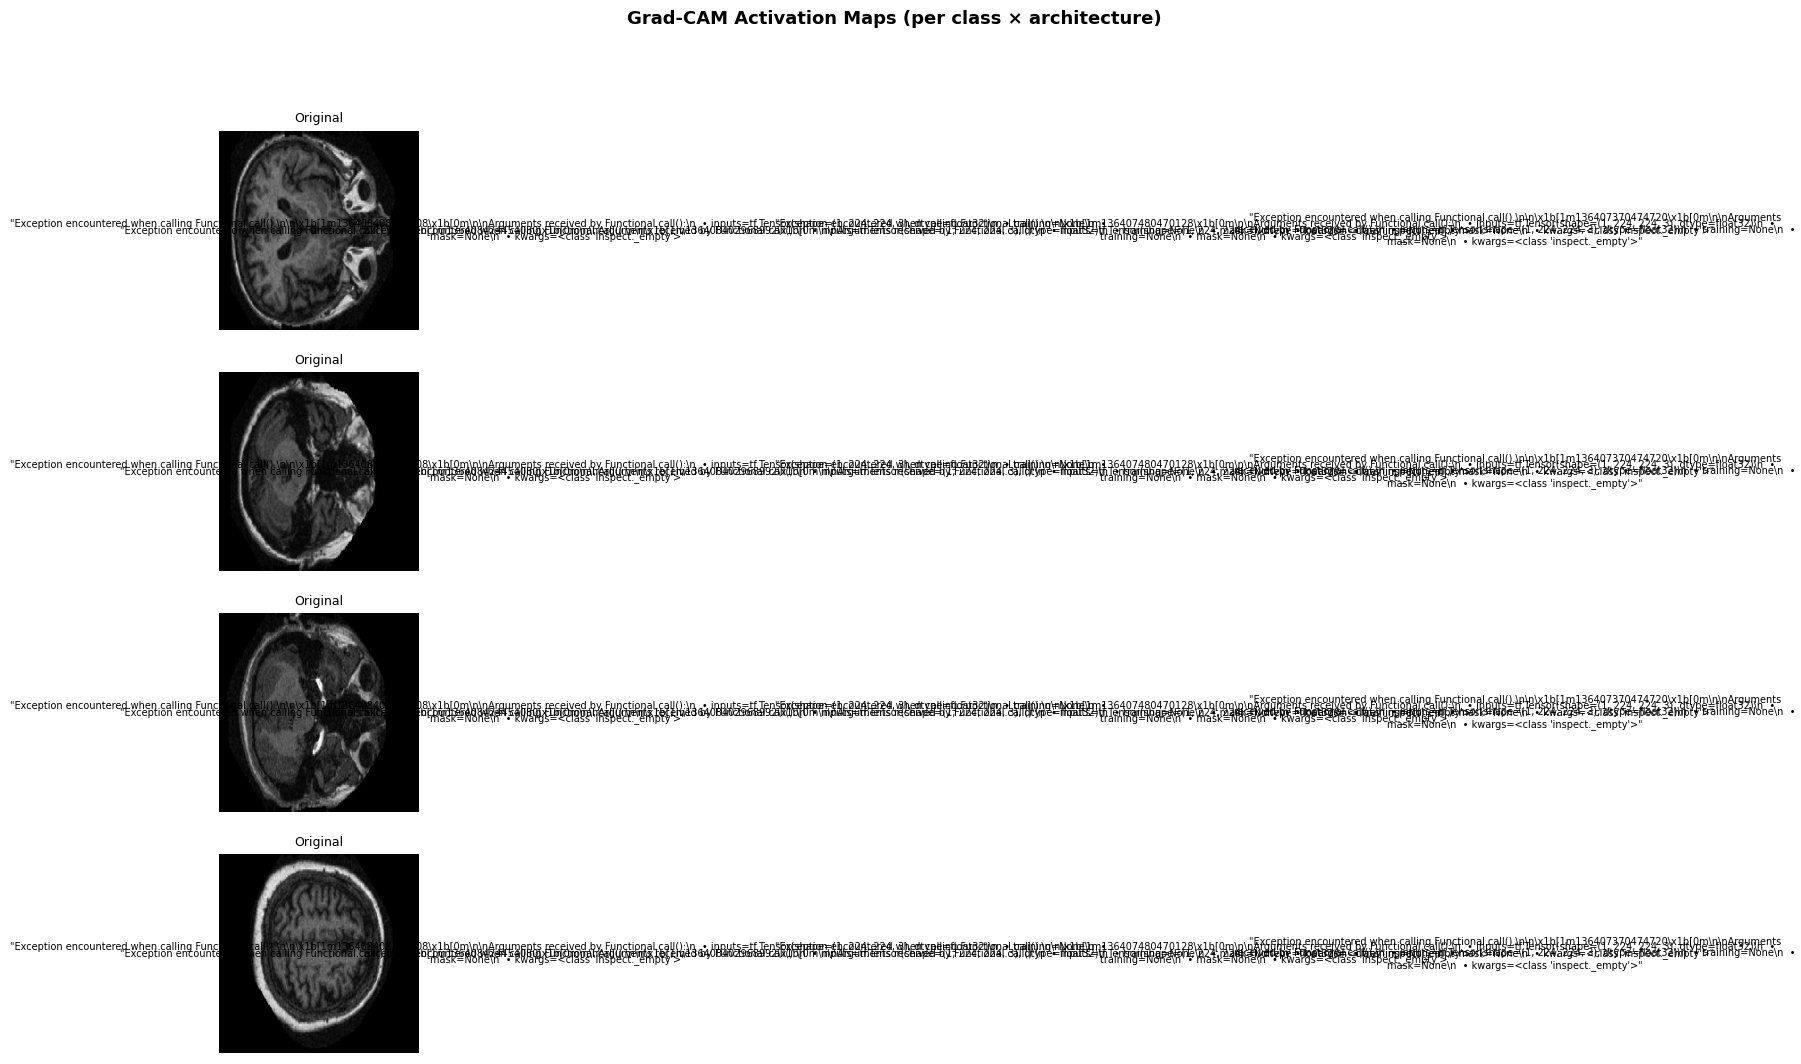

Grad-CAM saved to /content/gradcam_all.png


In [ ]:
# ─── Generate Grad-CAM for one sample per class, across all models ────────
test_root = Path(SUBSET_ROOT) / 'test'
sample_imgs = {cls: list((test_root / cls).glob('*'))[0] for cls in CLASSES}

fig, axes = plt.subplots(
    len(CLASSES), len(ARCHITECTURES) + 1,
    figsize=(3*(len(ARCHITECTURES)+1), 3*len(CLASSES))
)

for r, cls in enumerate(CLASSES):
    img_path = sample_imgs[cls]
    raw_img  = tf.keras.utils.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_arr  = tf.keras.utils.img_to_array(raw_img) / 255.0
    img_exp  = np.expand_dims(img_arr, axis=0)

    # Original image
    ax = axes[r, 0]
    ax.imshow(img_arr)
    ax.set_title('Original', fontsize=9)
    ax.set_ylabel(cls, fontweight='bold', fontsize=10)
    ax.axis('off')

    for c, (arch_name, model) in enumerate(MODELS.items()):
        ax = axes[r, c+1]
        try:
            conv_name = get_last_conv_layer(model)
            heatmap   = make_gradcam_heatmap(img_exp, model, conv_name)
            overlay   = overlay_gradcam(img_path, heatmap)
            ax.imshow(overlay)
            pred  = np.argmax(model.predict(img_exp, verbose=0))
            label = CLASSES[pred]
            ax.set_title(f'{arch_name}\nPred: {label}', fontsize=8)
        except Exception as e:
            ax.text(0.5, 0.5, str(e), ha='center', va='center', fontsize=7, wrap=True)
        ax.axis('off')

plt.suptitle('Grad-CAM Activation Maps (per class × architecture)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/gradcam_all.png', dpi=120, bbox_inches='tight')
plt.show()
print('Grad-CAM saved to /content/gradcam_all.png')

## 9 · Classification Report

In [ ]:
print('\n' + '='*70)
for arch_name, model in MODELS.items():
    train_gen, val_gen, test_gen = make_generators()
    test_gen.reset()
    preds = np.argmax(model.predict(test_gen, verbose=0), axis=1)
    trues = test_gen.classes
    print(f'\n── {arch_name} ──')
    print(classification_report(trues, preds, target_names=CLASSES))


Found 560 images belonging to 4 classes.
Found 120 images belonging to 4 classes.
Found 120 images belonging to 4 classes.

── VGG16 ──
                    precision    recall  f1-score   support

     Mild Dementia       0.00      0.00      0.00        30
 Moderate Dementia       0.57      0.13      0.22        30
      Non Demented       0.50      0.43      0.46        30
Very mild Dementia       0.28      0.80      0.41        30

          accuracy                           0.34       120
         macro avg       0.34      0.34      0.27       120
      weighted avg       0.34      0.34      0.27       120

Found 560 images belonging to 4 classes.
Found 120 images belonging to 4 classes.
Found 120 images belonging to 4 classes.

── ResNet50 ──
                    precision    recall  f1-score   support

     Mild Dementia       0.00      0.00      0.00        30
 Moderate Dementia       0.25      1.00      0.40        30
      Non Demented       0.00      0.00      0.00        30


## 10 · Summary Table & Best Model

In [ ]:
import pandas as pd

rows = []
for name, r in RESULTS.items():
    rows.append({
        'Architecture'   : name,
        'Test Accuracy'  : f"{r['test_acc']:.4f}",
        'Test Loss'      : f"{r['test_loss']:.4f}",
        'Train Time (min)': f"{r['time_min']:.1f}",
        'Params (M)'     : f"{r['params']/1e6:.1f}"
    })

df = pd.DataFrame(rows).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
print('\n📊 RESULTS SUMMARY')
print(df.to_string(index=False))

best = df.iloc[0]['Architecture']
print(f'\n🏆 Best standalone model: {best}')


📊 RESULTS SUMMARY
  Architecture Test Accuracy Test Loss Train Time (min) Params (M)
   MobileNetV2        0.4083    1.2378              2.6        2.6
   InceptionV3        0.3833    1.2973              2.6       22.4
         VGG16        0.3417    1.3546              3.7       14.9
      ResNet50        0.2500    1.4853              2.2       24.2
EfficientNetB0        0.2500    1.3901              3.0        4.4

🏆 Best standalone model: MobileNetV2


## 11 · Ensemble Strategy (Merge Two Best Models)

In [ ]:
# ─── Soft-voting ensemble of top-2 architectures ──────────────────────────
top2   = df.head(2)['Architecture'].tolist()
print(f'Ensemble of: {top2}')

train_gen, val_gen, test_gen = make_generators()
test_gen.reset()

all_probs = []
for name in top2:
    test_gen.reset()
    probs = MODELS[name].predict(test_gen, verbose=0)
    all_probs.append(probs)

# Simple average
ensemble_probs = np.mean(all_probs, axis=0)
ensemble_preds = np.argmax(ensemble_probs, axis=1)

test_gen.reset()
trues = test_gen.classes
ens_acc = (ensemble_preds == trues).mean()

print(f'\nEnsemble Test Accuracy: {ens_acc:.4f}')
print(classification_report(trues, ensemble_preds, target_names=CLASSES))

# Compare with individuals
print('Individual accuracies:')
for name in top2:
    print(f'  {name}: {RESULTS[name]["test_acc"]:.4f}')
print(f'  Ensemble:  {ens_acc:.4f}')

if ens_acc > max(RESULTS[n]['test_acc'] for n in top2):
    print('\n✅ Ensemble IMPROVES over individual models — merge is beneficial!')
else:
    print('\n⚠️  Ensemble does NOT improve — the best single model is sufficient.')

Ensemble of: ['MobileNetV2', 'InceptionV3']
Found 560 images belonging to 4 classes.
Found 120 images belonging to 4 classes.
Found 120 images belonging to 4 classes.

Ensemble Test Accuracy: 0.4917
                    precision    recall  f1-score   support

     Mild Dementia       0.44      0.37      0.40        30
 Moderate Dementia       0.51      0.67      0.58        30
      Non Demented       0.52      0.50      0.51        30
Very mild Dementia       0.48      0.43      0.46        30

          accuracy                           0.49       120
         macro avg       0.49      0.49      0.49       120
      weighted avg       0.49      0.49      0.49       120

Individual accuracies:
  MobileNetV2: 0.4083
  InceptionV3: 0.3833
  Ensemble:  0.4917

✅ Ensemble IMPROVES over individual models — merge is beneficial!


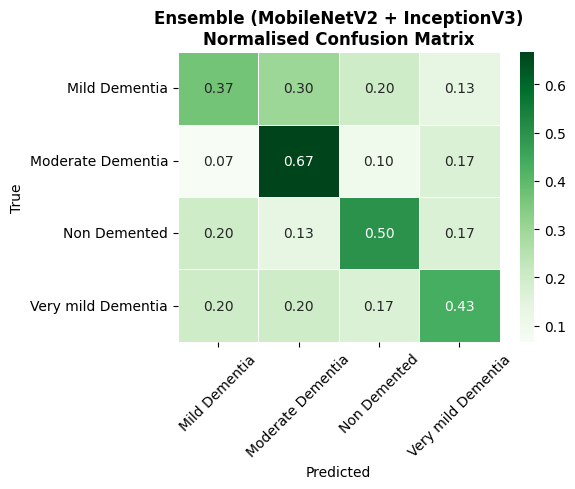

In [ ]:
# ─── Confusion matrix for ensemble ───────────────────────────────────────
cm = confusion_matrix(trues, ensemble_preds)
cm_n = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(6, 5))
sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=CLASSES, yticklabels=CLASSES,
            linewidths=0.5)
plt.title(f'Ensemble ({" + ".join(top2)})\nNormalised Confusion Matrix',
          fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('/content/ensemble_cm.png', dpi=120, bbox_inches='tight')
plt.show()

## 12 · Save Best Model & Results

In [ ]:
best_model = MODELS[best]
best_model.save(f'/content/{best}_alzheimer.keras')
print(f'Best model saved: /content/{best}_alzheimer.keras')

# Download all result images
from google.colab import files
for fname in ['training_curves.png', 'model_comparison.png',
              'confusion_matrices.png', 'gradcam_all.png', 'ensemble_cm.png']:
    path = f'/content/{fname}'
    if os.path.exists(path):
        files.download(path)

files.download(f'/content/{best}_alzheimer.keras')
print('All files downloaded.')

Best model saved: /content/MobileNetV2_alzheimer.keras


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files downloaded.


---
## 📝 Notes & Recommendations

### Architecture Characteristics

| Architecture | Strengths | Weaknesses | Best for |
|---|---|---|---|
| **VGG16** | Simple, proven, easy Grad-CAM | Heavy (138M params), slow | Baseline, interpretability |
| **ResNet50** | Residual connections, avoids vanishing gradients | Moderate size | General medical imaging |
| **InceptionV3** | Multi-scale feature extraction | Complex, needs larger input | Fine-grained features |
| **MobileNetV2** | Lightweight, fast inference | Lower capacity | Edge deployment |
| **EfficientNetB0** | Best accuracy/param ratio | Sensitive to hyperparams | Best accuracy target |

### When to Merge (Ensemble)?
- ✅ **Merge if** the two best models have different architectures (e.g., VGG + EfficientNet) → they capture complementary features
- ✅ **Merge if** individual accuracies are close (within 2%) → averaging smooths errors
- ❌ **Skip merge if** one model dominates by >3% — the weak model introduces noise
- 💡 **Advanced option**: Train a small meta-learner (stacking) instead of simple averaging

### Free Colab Tips
- Keep `MAX_PER_CLASS ≤ 300` and `EPOCHS ≤ 15`
- Train one model at a time if RAM is tight: comment out others in `ARCHITECTURES`
- Use `model.save()` after each model to avoid losing work on session reset
- Switch to **Colab Pro** for A100 GPU — trains 5x faster
